In [1]:
#Imports
from utils import DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

In [15]:
#Load and preprocess data
data_loader = DataLoader()
data_loader.load_dataset()
data_loader.preprocess_data()
# Split the data for evaluation
X_train, X_test, y_train, y_test = data_loader.get_data_split()
# Convert boolean/object features to numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)
# Oversample the train data
X_train, y_train = data_loader.oversample(X_train, y_train)
print(X_train.shape)
print(X_test.shape)

(7778, 21)
(1022, 21)


In [16]:
#Fit blackbox model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(f"F1 Score {f1_score(y_test, y_pred, average='macro')}")
print(f"Accuracy {accuracy_score(y_test, y_pred)}")


F1 Score 0.5471372488047577
Accuracy 0.9442270058708415


In [20]:
import dice_ml

dice_df = X_train.copy()
dice_df["stroke"] = y_train.values


data_dice = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=[
        "age",
        "avg_glucose_level",
        "bmi"
    ],
    outcome_name="stroke"
)


rf_dice = dice_ml.Model(
    model=rf,
    backend="sklearn"
)


explainer = dice_ml.Dice(
    data_dice,
    rf_dice,
    method="random"
)

In [25]:
print(rf.feature_names_in_)
print(X_test.columns)
print(X_train.dtypes)

['gender_Female' 'gender_Male' 'gender_Other' 'ever_married_No'
 'ever_married_Yes' 'work_type_Govt_job' 'work_type_Never_worked'
 'work_type_Private' 'work_type_Self-employed' 'work_type_children'
 'Residence_type_Rural' 'Residence_type_Urban' 'smoking_status_Unknown'
 'smoking_status_formerly smoked' 'smoking_status_never smoked'
 'smoking_status_smokes' 'age' 'hypertension' 'heart_disease'
 'avg_glucose_level' 'bmi']
Index(['gender_Female', 'gender_Male', 'gender_Other', 'ever_married_No',
       'ever_married_Yes', 'work_type_Govt_job', 'work_type_Never_worked',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'Residence_type_Rural', 'Residence_type_Urban',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes', 'age',
       'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'],
      dtype='str')
gender_Female                     float64
gender_Male                 

In [28]:
#Create diverse counterfactual explanations

import dice_ml

# Create DiCE dataframe
dice_df = X_train.copy()
dice_df["stroke"] = y_train.values


# Ensure numeric
dice_df = dice_df.astype(float)


# Dataset
data_dice = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=[
        "age",
        "avg_glucose_level",
        "bmi"
    ],
    outcome_name="stroke"
)


# Model
rf_dice = dice_ml.Model(
    model=rf,
    backend="sklearn"
)


# Explainer
explainer = dice_ml.Dice(
    data_dice,
    rf_dice,
    method="random"
)

In [33]:
# %% Create DiCE explainer using genetic algorithm

explainer = dice_ml.Dice(
    data_dice,
    rf_dice,
    method="genetic"
)

In [34]:
# %% Generate counterfactual explanations

input_datapoint = X_test.iloc[0:1].copy().astype(float)

cf = explainer.generate_counterfactuals(
    input_datapoint,
    total_CFs=3,
    desired_class="opposite"
)

cf.visualize_as_dataframe(
    show_only_changes=True
)

100%|██████████| 1/1 [02:13<00:00, 133.41s/it]

Query instance (original outcome : 0)


,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,70.0,0.0,0.0,72.559998,30.4,0



Diverse Counterfactual set (new outcome: 1)


,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,-,-,-,-,-,-,-,-,-,-,0.0,1.0,-,0.0,-,1.0,74.0,-,-,-,31.3,1.0
0,-,0.0,-,-,-,-,-,-,-,-,-,-,-,0.0,-,-,59.0,-,-,86.0,5.0,1.0
0,-,0.0,-,-,-,-,-,0.0,-,-,-,-,-,0.0,-,-,59.0,-,-,86.0,5.0,1.0


In [36]:
#Create feasible (conditional) Counterfactuals
features_to_vary=['avg_glucose_level',
                  'bmi',
                  'smoking_status_smokes']
permitted_range={'avg_glucose_level':[50,250],
                'bmi':[18, 35]}
# Now generating explanations using the new feature weights
cf = explainer.generate_counterfactuals(input_datapoint,
                                  total_CFs=3,
                                  desired_class="opposite",
                                  permitted_range=permitted_range,
                                  features_to_vary=features_to_vary)
# Visualize it
cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:22<00:00, 22.83s/it]

Query instance (original outcome : 0)


,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,70.0,0.0,0.0,72.559998,30.4,0



Diverse Counterfactual set (new outcome: 1)


,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,76.0,24.0,1.0
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,76.0,23.0,1.0
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,78.0,23.0,1.0


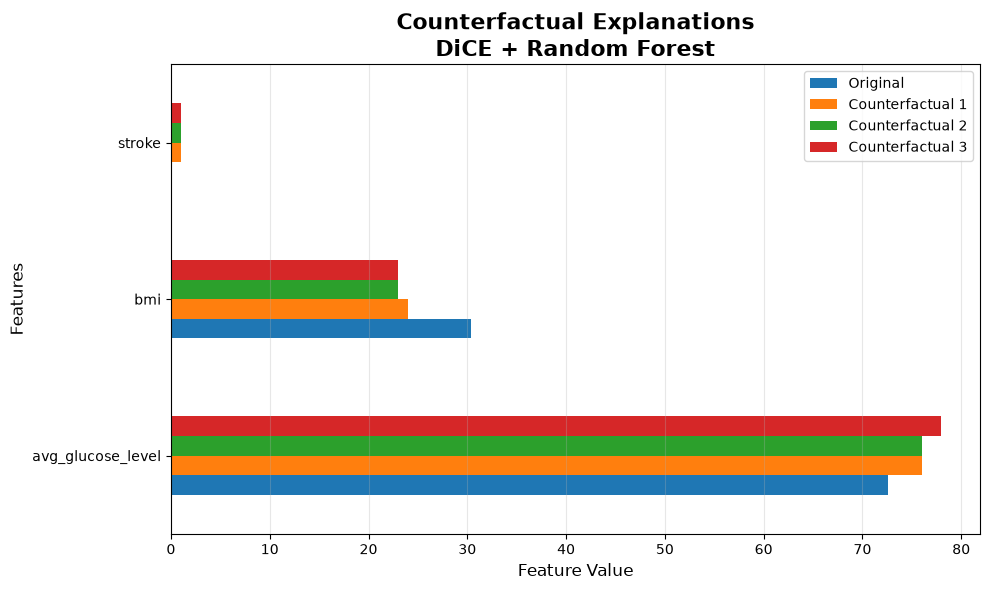

In [37]:
# %% Professional Counterfactual Visualization

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Get counterfactual dataframe
cf_df = cf.cf_examples_list[0].final_cfs_df

# Original instance
original = (
    cf.cf_examples_list[0]
    .test_instance_df
    .iloc[0]
)


# Select only changed features
changed_features = []

for feature in cf_df.columns:
    if not np.all(cf_df[feature] == original[feature]):
        changed_features.append(feature)


# Create visualization dataframe
visualization_df = pd.DataFrame()

visualization_df["Original"] = original[changed_features]

for i in range(len(cf_df)):
    visualization_df[f"Counterfactual {i+1}"] = (
        cf_df.iloc[i][changed_features]
    )


# Plot
fig, ax = plt.subplots(
    figsize=(10, 6)
)


visualization_df.plot(
    kind="barh",
    ax=ax
)


ax.set_title(
    "Counterfactual Explanations\nDiCE + Random Forest",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "Feature Value",
    fontsize=12
)

ax.set_ylabel(
    "Features",
    fontsize=12
)


ax.grid(
    axis="x",
    alpha=0.3
)


plt.tight_layout()

plt.show()

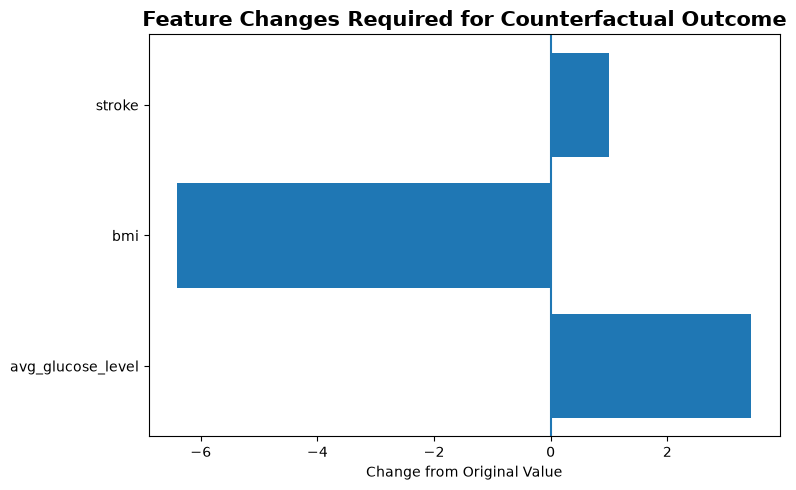

In [38]:
# %% Feature change visualization

changes = pd.DataFrame()

changes["Feature"] = changed_features

changes["Change"] = [
    cf_df.iloc[0][f] - original[f]
    for f in changed_features
]


plt.figure(figsize=(8,5))

plt.barh(
    changes["Feature"],
    changes["Change"]
)

plt.axvline(
    0
)

plt.title(
    "Feature Changes Required for Counterfactual Outcome",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Change from Original Value"
)

plt.tight_layout()

plt.show()